# Assignment 1: Curse of Dimensionality

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# 1. Local algorithms
The first activity shows how the performance of local algorithms is affected by the increase in the number of dimensions/features.

## Task 1.1: distances within the unit hypercube
Within a unit hypercube, $x\in[0,1]^n$, how do the average distance between 2 randomly chosen points evolves with the increase of dimensions?

In [2]:
# DON'T MODIFY THIS CELL
def plot_distance_histograms(distances):
    """
    Plots the histograms of distances for each dimension.
    
    INPUTS
    ----------
    distances : dictionary of narrays
        Dictionary the distances between pairs of points for different dimensions:
        {dim0:narray1, dim0:narray1, ...}
    """
    plt.figure(figsize=(6, 4))
    for dim, dist in distances.items():
        plt.hist(dist, bins=20, density=True, alpha=0.6, label=f'D={dim}')
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.tick_params(direction='in',axis='y')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def plot_loglog_scaling(distances):
    """
    Plots a log-log plot of average distance vs dimension and fits a linear regression.
    
    INPUTS
    ----------
    distances : dictionary of narrays
        Dictionary the distances between pairs of points for different dimensions:
        {dim0:narray1, dim0:narray1, ...}
    """
    dimensions = np.array(list(distances.keys()))
    avg_distances = np.array([np.mean(distances[dim]) for dim in dimensions])
    
    # Linear regression in log-log space: log(dist) = x * log(dim) + x0
    log_dims = np.log(dimensions)
    log_dists = np.log(avg_distances)
    
    slope, origin = np.polyfit(log_dims, log_dists, 1)
    
    # Create the regression line for plotting
    regression_line = np.exp(origin) * (dimensions ** slope)
    
    plt.figure(figsize=(6, 4))
    plt.loglog(dimensions, avg_distances, marker='o', linestyle='', color='blue', label='Mean distance')
    plt.loglog(dimensions, regression_line, linestyle='--', color='red', 
             label=f'Slope: {slope:.3f}')
    plt.xlabel('Dimensions')
    plt.ylabel('Distance')
    plt.legend()
    plt.tick_params(direction='in',which='both')
    plt.grid(which='both',ls="--", alpha=0.5)
    plt.show()

In [3]:
# ADD THE MISSING CODE
def distances_between_pairs(dim, num_pairs=1000):
    """
    Generate `num_pairs` random pairs of samples and compute their Euclidean distances.
    The samples are picked uniformly from a unit hypercube of `dim` dimensions: [0,1]^dim.

    INPUTS
    --------
    dim : integer
        Number of dimensions of the unit hypercube.
    num_pairs : integer
        Amount of pairs of samples.
    
    OUTPUTS
    --------
    distances : narray
        Array of length `num_pairs` with the Euclidean distances.
    """

    # YOUR CODE HERE

    # create as many random points so that it matches the num_pairs an let them have n_dims
    points_1 = np.random.rand(num_pairs, dim)
    points_2 = np.random.rand(num_pairs, dim)
    
    # calc the euclidian distance for every pair with norm (axis = 1 so it is calculated row-wise)
    distances = np.linalg.norm(points_1 - points_2, axis=1)

    # alternative by hand: vector length (here euclidian distance)
    # squared_diff = (points_1 - points_2) ** 2
    # sum_squared_diff = np.sum(squared_diff, axis=1)
    # distances = np.sqrt(sum_squared_diff)

    return distances

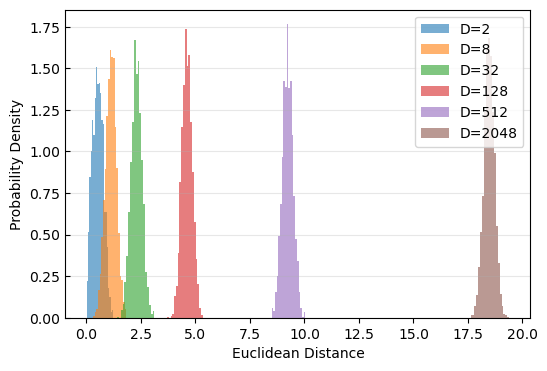

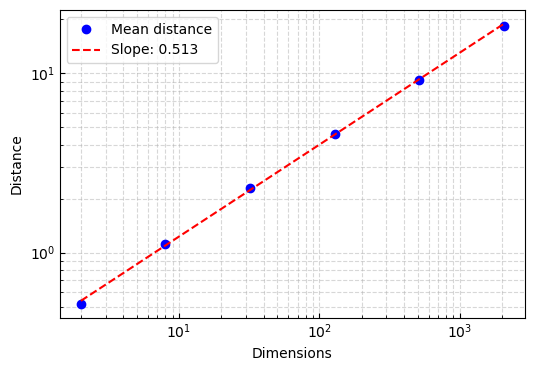

In [4]:
# Run this cell after implementing `distances_between_pairs`
n_pairs = 2000
dims_to_test = [2, 8, 32, 128, 512, 2048]
distance_data = {dim:distances_between_pairs(dim, n_pairs) for dim in dims_to_test}
plot_distance_histograms(distance_data)
plot_loglog_scaling(distance_data)

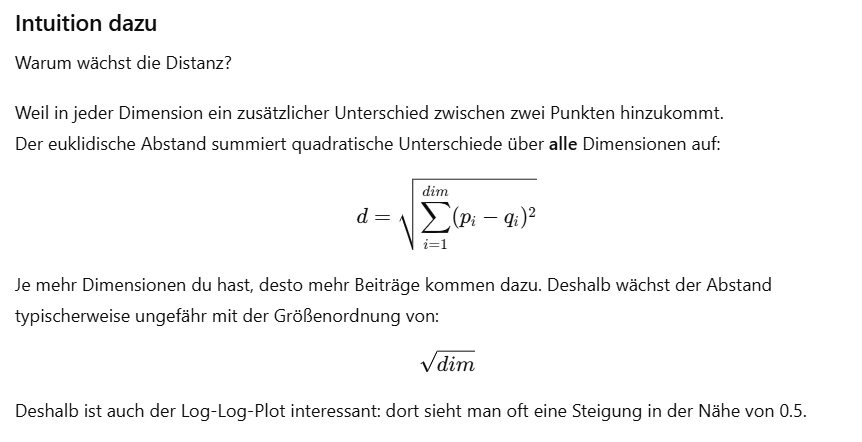

## Task 1.2: Neighbor distances between 2 classes
For this task we have 2 classes of data (crosses and circles) with 2 features that follow Gaussian distributions. Let's plot them in the ~hyper~plane.

In [5]:
# DON'T MODIFY THIS CELL
def plot_classes(crosses, circles):
    """
    Plots the samples in the plane.
    """
    plt.figure(figsize=(5, 5))
    plt.scatter(crosses[:, 0], crosses[:, 1], c='tab:orange', marker='+')
    plt.scatter(circles[:, 0], circles[:, 1], edgecolors='tab:blue', facecolors='none', marker='o')
    
    plt.tick_params(direction='in', which='both')
    plt.grid(ls="--", alpha=0.5)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


def plot_distance_separation(dist_same, dist_diff, title=None):
    """
    Plots the histograms comparing intra-class and inter-class distances.
    """
    plt.figure(figsize=(6, 4))
    plt.hist(dist_same, bins=40, density=True, alpha=.7, color='tab:orange', label='Same category')
    plt.hist(dist_diff, bins=40, density=True, alpha=.7, color='tab:purple', label='Different category')

    if not title==None:
        plt.title(title)
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.tick_params(direction='in', axis='y')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_distance_grid(results_dict):
    """
    Plots a grid of histograms comparing intra-class and inter-class 
    distances across different noise levels and added dimensions.
    result_dict = {(noise_std1, num_features1): (dist_same_array_11, dist_diff_array_11),
                   (noise_std1, num_features2): (dist_same_array_12, dist_diff_array_12),
                   (noise_std2, num_features1): (dist_same_array_21, dist_diff_array_21), 
                   ...}
    """
    stds = sorted(set(key[0] for key in results_dict))
    dims = sorted(set(key[1] for key in results_dict))
    
    fig, axes = plt.subplots(len(stds), len(dims), figsize=(15, 12))
    
    for ii, std in enumerate(stds):
        for jj, dim in enumerate(dims):
            ax = axes[ii, jj]
            dist_same, dist_diff = results_dict[(std, dim)]
            
            # Plot histograms
            ax.hist(dist_same, bins=40, density=True, alpha=.7, color='tab:orange', label='Same category')
            ax.hist(dist_diff, bins=40, density=True, alpha=.7, color='tab:purple', label='Different category')
            
            # Formatting
            ax.set_title(f"Noise Std: {std} | Extra Dims: {dim}")
            ax.tick_params(direction='in', axis='y')
            ax.grid(axis='y', alpha=0.3)
            
            # Only add axis labels to the outer edge subplots to avoid clutter
            if ii == len(stds) - 1:
                ax.set_xlabel('Euclidean Distance')
            if jj == 0:
                ax.set_ylabel('Probability Density')
                
            # Add the legend only to the top-left subplot
            if ii == 0 and jj == 0:
                ax.legend()
                
    plt.tight_layout()
    plt.show()

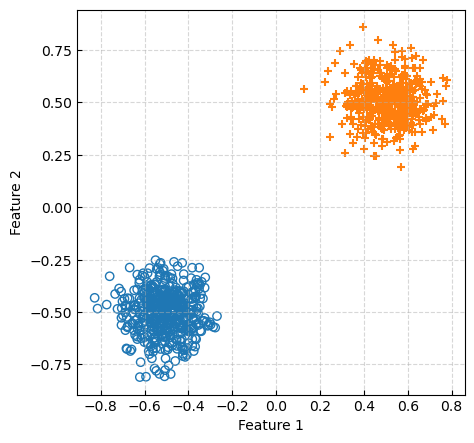

In [6]:
# DON'T MODIFY THIS CELL
n_samples = 500
std = .1
crosses = np.random.normal(loc=[.5,.5], scale=std, size=(n_samples, 2))
circles = np.random.normal(loc=[-.5,-.5], scale=std, size=(n_samples, 2))
plot_classes(crosses, circles)

* Compute the distance between samples from the same category, crosses and crosses, and between samples from different category, crosses and circles.

Visualize the results with the predefined function `plot_distance_separation`.

In [7]:
# HERE'S THE TEMPLATE FOR THE FUNCTION TO COMPUTE DISTANCES.
def compute_class_distances(crosses, circles):
    """
    Compute distances between the same sample type and between different sample types.
    
    INPUTS
    --------
    crosses : ndarray
        Array containing samples of the first class. Shape: (N, D).
    circles : ndarray
        Array containing samples of the second class. Shape: (N, D).
        
    OUTPUTS
    --------
    dist_same : ndarray
        Distances between shifted samples within the 'crosses' class. Shape: (N,).
    dist_diff : ndarray
        Distances between samples of 'crosses' and 'circles'. Shape: (N,).
    """
    # YOUR CODE HERE
    
    # distances between crosses (shifted pairs -> shifted bc no calculation should be done twice)
    dist_same = np.linalg.norm(crosses[1:] - crosses[:-1], axis=1)
    
    # distances between crosses and circles
    dist_diff = np.linalg.norm(crosses - circles, axis=1)

    return dist_same, dist_diff

In such dataset, local techniques like K-nearest neighbors and clustering may work. But what happens if useless features are included?
* Generate a function that takes your 2D data, `crosses` and `circles`, and attach them new features sampled from a Gaussian distribution centered at the origin.

You must be able to chose the number of new features and the standard deviation of the noise (common to all features). 

In [8]:
# ADD NOISY HIGH-DIMENSIONAL FEATURES WITH THE FOLLOWING FUNCTION (THAT YOU MUST COMPLETE)
def noisy_extra_features(data, num_features, std, loc=0.0):
    """
    Appends additional dimensions to the original features sampled from a Gaussian distribution.
    
    INPUTS
    --------
    data : narray
        Origianl 2-dimensional narray with N samples. Shape: (N,2).
    num_features : int
        The number of extra noisy dimensions to add.
    std : float
        The standard deviation of the Gaussian noise distribution.
    loc : float
        The mean (center) of the Gaussian noise distribution. Centered at the origin by default.

    OUTPUTS
    --------
    expanded_data : narray
        narray with original data + additional features. Shape: (N,2+num_features).
    """
    # YOUR CODE HERE
    
    # extract number of feature
    N = data.shape[0]
    
    # create noise
    noise = np.random.normal(loc=loc, scale=std, size=(N, num_features))
    
    # add noise
    expanded_data = np.hstack((data, noise))
    
    return expanded_data

* Use the function `noisy_extra_features` to generate a dictionary of distances between equal and different classes. Different dictionary entries must use different noise intensity `noise_stds` and number of extra features `extra_dims`:
```
result_dict = {(noise_stds1, extra_dims1): (dist_same_array_11, dist_diff_array_11),
               (noise_stds1, extra_dims2): (dist_same_array_12, dist_diff_array_12),
               (noise_stds2, extra_dims1): (dist_same_array_21, dist_diff_array_21), 
               ...}
```
* Generate a dictionary for `noise_stds`$\in[0.1, 0.2, 0.5]$ and `extra_dims`$\in[10, 20, 50]$.
Plot the dictionary with the function `plot_distance_grid`. 

* What do you observe? How would local methods perform in different cases?

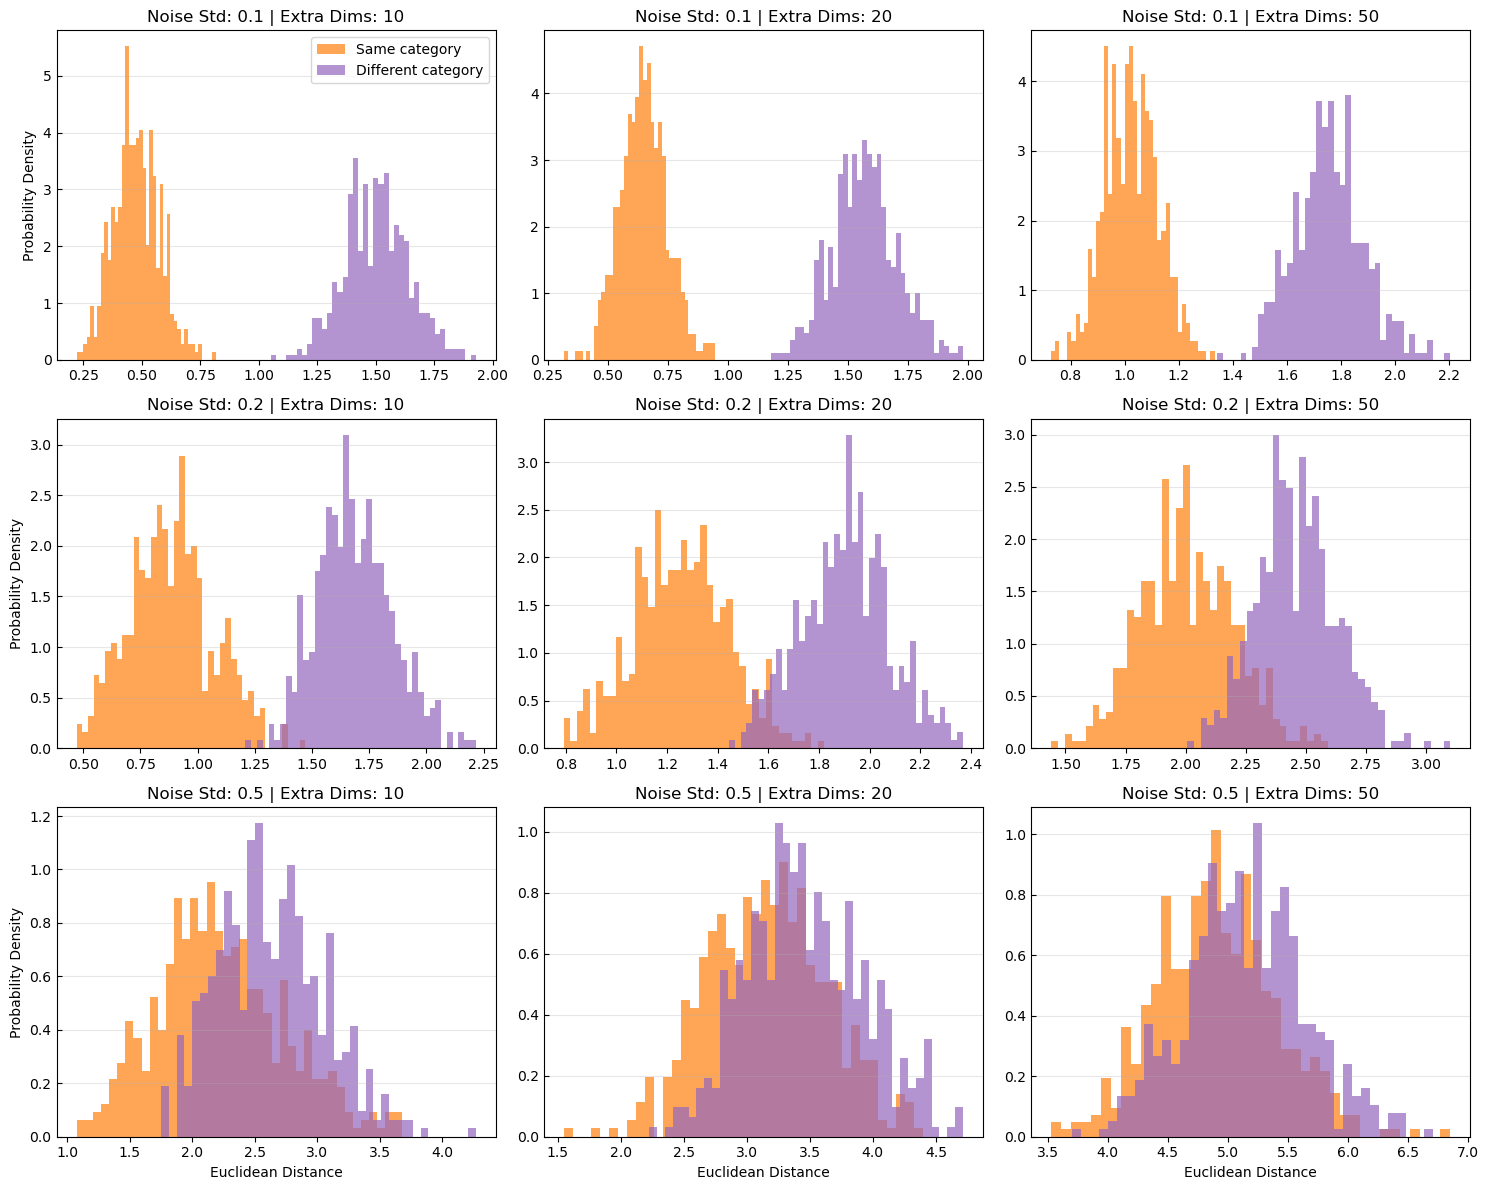

In [9]:
# Recycle the vectors `circles` and `crosses`, compute and store distances...
experiment_results = {}
for std in [0.1, 0.2, 0.5]:
    for dim in [10, 20, 50]:
        # YOUR CODE HERE
        
        # add noisy features
        crosses_noisy = noisy_extra_features(crosses, dim, std)
        circles_noisy = noisy_extra_features(circles, dim, std)
        
        # compute distances
        dist_same, dist_diff = compute_class_distances(crosses_noisy, circles_noisy)
        
        # store results
        experiment_results[(std, dim)] = (dist_same, dist_diff)
        
# and finally plot them
plot_distance_grid(experiment_results)

Adding noisy dimensions increases both intra-class and inter-class distances. As the dimensionality grows, the distributions of these distances start to overlap. This makes it harder for distance-based methods such as k-nearest neighbors to separate the classes, illustrating the curse of dimensionality.

# 2. High dimensional Monte Carlo integration
The integral of a function $f(\mathbf{x})$ on some space $\Omega\subset\mathbb{R}^m$ is given by:
$$I = \int_{\Omega}f({\mathbf{x}}) \, d{\mathbf{x}}.$$
If we know the volume of $\Omega$, $V = \int_{\Omega}d{\mathbf{x}}$, we can approximate the integral $I$ by sampling points from $\Omega$ uniformly. For a *large enough* number of samples
$$I \approx V \frac{1}{N} \sum_{i=1}^N f({\mathbf{x}}_i) = V \langle f\rangle.$$
This is (naive) [Monte Carlo Integration](https://en.wikipedia.org/wiki/Monte_Carlo_integration). In this activity we apply MC integration to multidimensional functions. Our goal is not to better estimate the integrals, designed to be 1, but to see how the number of samples that we need to achieve convergence increases with the number of dimensions.

In [10]:
# DON'T MODIFY THIS CELL
def hypercube_vertices(dim, loc=0.25):
    """
    Generates the 2^dim vertices of the hypercube.
    """
    return np.array(list(itertools.product([-loc, loc], repeat=dim)))


def gaussian_blobs(points, vertices=None, sigma=0.05):
    """
    Evaluates the sum of Gaussians at given points. 
    """
    dimension = points.shape[-1]
    norm_const = (np.sqrt(2 * np.pi) * sigma)**dimension

    if vertices is None:
        vertices = hypercube_vertices(dimension, loc=.25)
    
    # Broadcasted difference: (batch_size, 2^D, D)
    diff = points[:, None, :] - vertices[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)
    
    f_vals = np.sum(np.exp(-sq_dist / (2 * sigma**2)), axis=-1) / norm_const
    return f_vals / len(vertices) # the integral is 1 no matter the dimensions


def plot_mc_convergence(integral_dict):
    """
    Plots the convergence of MC integration vs true value across dimensions.
    """
    plt.figure(figsize=(6, 4))

    for dim, (steps, value, std) in integral_dict.items():
        plt.errorbar(x=steps,y=value,yerr=std,capsize=4, label=f'D={dim}')
        
    plt.axhline(1.0, color='black', linestyle='--') # the value of the integral
    plt.xlabel('Number of samples')
    plt.ylabel('Integral estimation')
    plt.legend()
    plt.tick_params(direction='in', which='both')
    plt.grid(which='both', ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

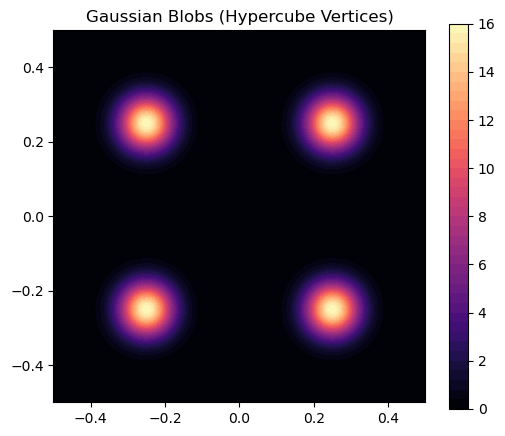

In [11]:
# DON'T MODIFY THIS CELL
x = np.linspace(-0.5, 0.5, 300)
y = np.linspace(-0.5, 0.5, 300)
X, Y = np.meshgrid(x, y)
grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
Z_blobs = gaussian_blobs(grid_points, sigma=0.05).reshape(X.shape)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))

# Plot Vertices
c1 = ax1.contourf(X, Y, Z_blobs, levels=50, cmap='magma')
ax1.set_title('Gaussian Blobs (Hypercube Vertices)')
ax1.set_aspect('equal')
fig.colorbar(c1, ax=ax1)
plt.show()

## Task 2.1 MC integration in the unit hypercube (centered in the origin)
The Gaussian blobs have a very small variance: 0.05. Therefore, as they are located at $x=(\pm 0.25,\pm 0.25,...)\in\mathbb{R}^d$ we can truncate their integral within the hypercube $[-0.5,0.5]^d$. 

* Implement a MC integral of the function `gaussian_blobs` within the hypercube $[-0.5,0.5]^d$ for $d\in[2,3,5,8]$. Plot them using the function `plot_mc_convergence`.

HINT: larger dimensions may require millions of samples, but you don't need to store them all or compute them at once.

In [12]:
def monte_carlo_integral(function, input_dimension, vmin=-.5, vmax=.5, 
                           num_samples=int(1e6), batch_size=1000, repetitions=4):
    """
    Monte Carlo integration with batching and statistical repetitions.
    
    Parameters
    ----------
    function : callable
        A function that takes an (N, D) numpy array of points and returns N values.
    input_dimension : int
        The dimensionality of the integration space (D).
    vmin, vmax : float or array-like
        The lower and upper bounds for uniform sampling. Can be a scalar (applied 
        to all dimensions) or a 1D array of length D.
    num_samples : int
        Total number of samples to draw per repetition.
    batch_size : int
        Number of samples to draw and evaluate at once. Data is recorded only at these intervals.
    repetitions : int
        Number of independent MC runs to compute mean and standard deviation.
        
    Returns
    -------
    sample_counts : 1D array
        The cumulative number of samples at each recording step (x-axis for plotting).
    mean_estimates : 1D array
        The average integral estimate across all repetitions.
    std_estimates : 1D array
        The standard deviation of the integral estimates across all repetitions.
    """
    # YOUR CODE HERE

    # extract volume boundaries 
    # full creates you an array of the desired input dimension (take scalar or if array --> convert to np.array)
    # eg. np.full(2, -0.5) --> array([-0.5, -0.5])
    vmin = np.full(input_dimension, vmin) if np.isscalar(vmin) else np.asarray(vmin)
    vmax = np.full(input_dimension, vmax) if np.isscalar(vmax) else np.asarray(vmax)
    
    # calculate the volume (here always one bc 0.5 - (-0.5) = 1)
    # if boundaries were different eg. [0,2]^3 then --> np.prod([2,2,2]) = 8
    volume = np.prod(vmax - vmin)
    
    #get n of steps (floor division)
    num_steps = num_samples // batch_size

    # get total n of samples after each batch eg. batch one 10.000 samples and after batch 2 20.000 samples
    # num_steps + 1 bc arange start till stop-1 so we get n_steps
    sample_counts = np.arange(1, num_steps + 1) * batch_size
    
    # init estimate with zeros of rep x steps
    all_estimates = np.zeros((repetitions, num_steps))
    
    # loop over reps
    for rep in range(repetitions):
        # after each rep the sum has to be set to zero
        running_sum = 0.0
        
        # loop over batches
        for step in range(num_steps):
            #draw random points of size batch x input dim with given boundaries
            points = np.random.uniform(low=vmin, high=vmax, size=(batch_size, input_dimension))

            # apply function e.g. gaussian blobs --> N, D
            f_values = function(points)
            
            # update sum (skalar)
            running_sum += np.sum(f_values)

            # update sample count (start at 0 so step + 1)
            current_count = (step + 1) * batch_size
            
            # save current MC approx.
            all_estimates[rep, step] = volume * running_sum / current_count
    
    # calculate mean and std for every estimates (axis=0 to do it columnwise)
    mean_estimates = np.mean(all_estimates, axis=0)
    std_estimates = np.std(all_estimates, axis=0)
    
    return sample_counts, mean_estimates, std_estimates

In [13]:
stored_data = {}
for dim in [2,3,5,8]:
    stored_data[dim] = monte_carlo_integral(gaussian_blobs, dim,
                                            num_samples=int(1e6), batch_size=int(1e4), repetitions=3)

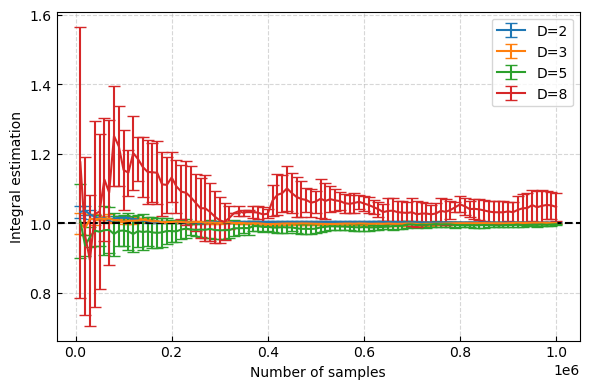

In [14]:
plot_mc_convergence(stored_data)

## Task 2.2: exploiting symmetry
* Consider the function `gaussian_blobs` in 2 dimensions $f_2(x):\mathbb{R}^2\rightarrow\mathbb{R}$. Define 4 different matrices, $M$, such that: $f_2(M x) = f_2(x)$ for all $x\in\mathbb{R}^2$.
That is, define 4 transformations on the input space that lead to the same value of `gaussian_blobs`.
Show 2 more for the 3-dimensional case $f_3(x):\mathbb{R}^3\rightarrow\mathbb{R}$.

Hint: think about discrete transformations in the space.

* BONUS: notice that taking two matrices, $M_i$ and $M_j$, from the previous solution leads to a new one: $f_3(M_i x)=f_3(M_j x) = f_3(M_i M_j x) = f_3(x)$. How many distinct matrices $M$ exist in 3 dimensions such that they cannot be obtained as the product of other matrices. 

* In the previous task we integrated the function within a unit hypercube. Keeping the same precision, which subsection of the hypercube do we need to sample in 2 dimensions? And for 3 dimensions? Think about the transformations you just described with matrices.



## Task 2.2: exploiting symmetry

The function `gaussian_blobs` is symmetric because its Gaussian centers are placed at all hypercube vertices.

### 2D case

Four matrices \(M\) such that \(f_2(Mx)=f_2(x)\) are:

\[ identity
\begin{pmatrix}
1 & 0\\
0 & 1
\end{pmatrix},

mirror/flip x-axis

\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix},

mirror/flip y-axis

\begin{pmatrix}
-1 & 0\\
0 & 1
\end{pmatrix},

mirror/flip around center (180 degree)

\begin{pmatrix}
-1 & 0\\
0 & -1
\end{pmatrix}
\]

These correspond to identity and sign flips of the coordinates.  
They leave the set of Gaussian centers unchanged up to permutation.

### 3D case

Two more examples in 3D are:

\[ 
  flipping along z-coordinate
\begin{pmatrix}
1 & 0 & 0\\
0 & 1 & 0\\
0 & 0 & -1
\end{pmatrix}

and switching x and y- coordinate 

\begin{pmatrix}
0 & 1 & 0\\
1 & 0 & 0\\
0 & 0 & 1
\end{pmatrix}
\]

Again, these transformations only permute the hypercube vertices, so the function value is unchanged.

### Bonus

In 3D, all such symmetry matrices are signed permutation matrices:

- \(3! = 6\) coordinate permutations
- \(2^3 = 8\) sign choices

Hence there are

\[
6 * 8 = 48
\]

distinct symmetry matrices in total.

### Reduced integration domain

Because of symmetry:

- in **2D**, it is enough to sample one quadrant, e.g.
  \[
  [0,0.5]^2
  \]
  and multiply the result by 4.

- in **3D**, it is enough to sample one octant, e.g.
  \[
  [0,0.5]^3
  \]
  and multiply the result by 8.

This keeps the same precision while reducing the sampled region.

# 3. Mathematical derivation of the Curse of Dimensionality

Here, we provide a more rigorous mathematical treatment of the Curse of Dimensionality (CoD) example discussed in the lecture. Let us first establish the notation. 

We define the function class $\mathcal{F}=\left\{ f(x)=\sum_{z \in H_d} c_z \varphi(x-z) \right\}$, where: 
* $\varphi$ is a non-negative, sufficiently smooth "Gaussian blob" supported on $B(0,r)$, the ball of radius $r$ centered at $0$.
* $H_d=\left\{ (z_1,\cdots, z_d)\mid z_i=\pm 1 \right\}$ represents the vertices of the $d$-dimensional hypercube, and the coefficients $c_z$ take values in $\{-1, 1\}$.
* $r$ is chosen such that the balls $B(z,r)$ centered at each $z \in H_d$ are mutually disjoint.
* For any pair $x$, $x'$, $|f(x)-f(x')|\leq||x-x'||$. That is, all functions in $\mathcal{F}$ are $1$-Lipschitz, or $\mathcal{F} \subseteq \text{Lip}(1)$.

*The function from the previous question was **almost** an element of $\mathcal{F}$, with all $c_z=+1$. The difference is that the previous "blobs" were defined in the whole space. Here only in a ball. Also, the previous blobs were a bit more pointy than a $1$-Lipschitz function.* 

We want to show that at least $N=2^d$ samples are required to learn functions in $\mathcal{F}$ effectively, thereby demonstrating that learning the class of $1$-Lipschitz functions is subject to the curse of dimensionality. 

We assume the data distribution $X \sim \text{Unif}(\cup_{z \in H_d} B(z,r))$, meaning the probability is uniform within the balls, and the probability mass of each ball is the same: $2^{-d}$. Given an i.i.d. sample $S=(x_i, f(x_i))_{i=1}^N$ generated by some unknown $f \in \mathcal{F}$, our goal is to find an estimator $\hat{f}$ that minimizes the worst-case expected error over the class $\mathcal{F}$. In other words, we want the quantity $\sup_{f \in \mathcal{F}} \mathbb{E}_{x \sim X} (\hat{f}(x)-f(x))^2$ to be as small as possible. 

Specifically, however, we will establish a lower bound of the form:
\begin{align*}
\inf_{\hat{f}} \sup_{f \in \mathcal{F}} \mathbb{E}_{x \sim X} (\hat{f}(x)-f(x))^2 \geq \left(1- \frac{N}{2^d}\right)s,
\end{align*}
where $s=\mathbb{E}_{x \sim X} f(x)^2$. This implies that a sample size of at least $N=2^d$ is necessary to strictly decrease the generalization error to $0$.

A crucial step in proving this is introducing a prior over the coefficients $c_z$, such that each $c_z \in \{-1, 1\}$ is selected with probability $\frac{1}{2}$, independent of $X$. By lower-bounding the minimax risk with the Bayes risk over this prior, we obtain the following chain of inequalities:
\begin{align*}
\inf_{\hat{f}} \sup_{f \in \mathcal{F}} \mathbb{E}_{x \sim X} (\hat{f}(x)-f(x))^2 \geq \inf_{\hat{f}} \mathbb{E}_{x,c} (\hat{f}(x)-f(x))^2 \geq \left(1- \frac{N}{2^d}\right)s \quad (*)
\end{align*}

$\mathbb{E}_{x \sim X}f(x)$ is the expected value of a function $f$ evaluated at random samples $x$, from a distribution $X$. Moreover, $\mathbb{E}_{x \sim X}f(x)^n$ is the n-th moment of $f$.

We will establish this lower bound through a series of dedicated steps.

## Task 3.1:

As a first step, show that computing the second moment of any $f \in \mathcal{F}$ reduces to evaluating it solely for the basis function $\varphi$. Specifically, prove that $s=\mathbb{E}_{x \sim X} f(x)^2=\mathbb{E}_{u \sim \text{Unif}( B(0,r)) } \varphi(u)^2$. Use this result to conclude that $s= \mathbb{E}_{x,c} [ f(x)^2 \mid x \in B(z,r) ]$ for any $z \in H_d$.

## Solution 

We want to show that the second moment of any function $f \in \mathcal{F}$ reduces to the second moment of the basis function $\varphi$.

---

### Definition of the function

We have:

$$
f(x) = \sum_{z \in H_d} c_z \, \varphi(x - z), \quad c_z \in \{-1, 1\}
$$

Each function is a sum of Gaussian blobs centered at the vertices $z$.

---

### Key observation

Each function $\varphi(x - z)$ is supported only inside the ball $B(z, r)$, and the balls do **not overlap**.

Therefore, for any point $x$, there exists at most one $z$ such that:

$$
x \in B(z, r)
$$

So in that case:

$$
f(x) = c_z \, \varphi(x - z)
$$

---

### Squaring the function

We square both sides:

$$
f(x)^2 = (c_z \, \varphi(x - z))^2
$$

Since $c_z \in \{-1,1\}$, we have:

$$
c_z^2 = 1
$$

Thus:

$$
f(x)^2 = \varphi(x - z)^2
\quad \text{for } x \in B(z,r)
$$

---

### Computing the expectation

We compute:

$$
s = \mathbb{E}_{x \sim X}[f(x)^2]
$$

The distribution is:

$$
X \sim \mathrm{Unif}\left(\bigcup_{z \in H_d} B(z,r)\right)
$$

Each ball has probability:

$$
\mathbb{P}(x \in B(z,r)) = 2^{-d}
$$

So we can write:

$$
s = \sum_{z \in H_d} \mathbb{P}(x \in B(z,r)) \cdot 
\mathbb{E}[f(x)^2 \mid x \in B(z,r)]
$$

---

### Substitute the expression

From before:

$$
f(x)^2 = \varphi(x - z)^2
$$

So:

$$
\mathbb{E}[f(x)^2 \mid x \in B(z,r)]
=
\mathbb{E}[\varphi(x - z)^2 \mid x \in B(z,r)]
$$

---

### Change of variables

Let:

$$
u = x - z
$$

Then:

- if $x \sim \mathrm{Unif}(B(z,r))$
- then $u \sim \mathrm{Unif}(B(0,r))$

So:

$$
\mathbb{E}[\varphi(x - z)^2 \mid x \in B(z,r)]
=
\mathbb{E}_{u \sim \mathrm{Unif}(B(0,r))}[\varphi(u)^2]
$$

---

### Final result

This does not depend on $z$, so all terms are identical:

$$
s = \mathbb{E}_{x \sim X}[f(x)^2]
=
\mathbb{E}_{u \sim \mathrm{Unif}(B(0,r))}[\varphi(u)^2]
$$

---

### Conclusion

We also conclude that for any $z \in H_d$:

$$
s = \mathbb{E}_{x,c}[f(x)^2 \mid x \in B(z,r)]
$$

---

### Intuition

- Only one blob contributes at each point
- Squaring removes the sign $c_z$
- All regions behave identically after shifting

Therefore, everything reduces to a single blob $\varphi$ on $B(0,r)$.

## Task 3.2:

Next, for any $z \in H_d$, establish the following lower bound on the conditional risk:
\begin{align*}
\inf_{\hat{f}} \mathbb{E}_{x,c} \left[ (\hat{f}(x)-f(x))^2 \mid x \in B(z,r) \right] \geq s.
\end{align*}

## Solution

We want to prove that for any $z \in H_d$,

$$
\inf_{\hat{f}} \mathbb{E}_{x,c} \left[ (\hat{f}(x)-f(x))^2 \mid x \in B(z,r) \right] \geq s.
$$

---

### Step 1: Restrict to one ball

Fix any $z \in H_d$ and assume that $x \in B(z,r)$.

Since the balls are disjoint, only the blob centered at $z$ contributes. Therefore,

$$
f(x) = c_z \, \varphi(x-z),
\qquad c_z \in \{-1,1\}.
$$

So inside the ball $B(z,r)$, the only unknown part is the sign $c_z$.

---

### Step 2: Write the conditional risk

For any estimator $\hat{f}$, the conditional squared error is

$$
(\hat{f}(x)-f(x))^2
=
(\hat{f}(x)-c_z\varphi(x-z))^2.
$$

Taking expectation over both $x$ and the random sign $c_z$, conditioned on $x \in B(z,r)$, gives

$$
\mathbb{E}_{x,c}\left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right]
=
\mathbb{E}_{x,c_z}\left[(\hat{f}(x)-c_z\varphi(x-z))^2 \mid x \in B(z,r)\right].
$$

---

### Step 3: Average over the two possible signs

Since $c_z = +1$ and $c_z = -1$ each occur with probability $\tfrac12$,

$$
\mathbb{E}_{c_z}\left[(\hat{f}(x)-c_z\varphi(x-z))^2\right]
=
\frac12 (\hat{f}(x)-\varphi(x-z))^2
+
\frac12 (\hat{f}(x)+\varphi(x-z))^2.
$$

Expand both terms:

$$
(\hat{f}(x)-\varphi(x-z))^2
=
\hat{f}(x)^2 - 2\hat{f}(x)\varphi(x-z) + \varphi(x-z)^2,
$$

$$
(\hat{f}(x)+\varphi(x-z))^2
=
\hat{f}(x)^2 + 2\hat{f}(x)\varphi(x-z) + \varphi(x-z)^2.
$$

Adding them together and dividing by $2$ gives

$$
\frac12 (\hat{f}(x)-\varphi(x-z))^2
+
\frac12 (\hat{f}(x)+\varphi(x-z))^2
=
\hat{f}(x)^2 + \varphi(x-z)^2.
$$

Hence,

$$
\mathbb{E}_{c_z}\left[(\hat{f}(x)-c_z\varphi(x-z))^2\right]
=
\hat{f}(x)^2 + \varphi(x-z)^2.
$$

---

### Step 4: Take expectation over $x$

Now take expectation over $x \mid x \in B(z,r)$:

$$
\mathbb{E}_{x,c}\left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right]
=
\mathbb{E}_{x}\left[\hat{f}(x)^2 \mid x \in B(z,r)\right]
+
\mathbb{E}_{x}\left[\varphi(x-z)^2 \mid x \in B(z,r)\right].
$$

Since $\hat{f}(x)^2 \geq 0$, we obtain the lower bound

$$
\mathbb{E}_{x,c}\left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right]
\geq
\mathbb{E}_{x}\left[\varphi(x-z)^2 \mid x \in B(z,r)\right].
$$

---

### Step 5: Identify this quantity with $s$

From Task 3.1, we already know that

$$
\mathbb{E}_{x}\left[\varphi(x-z)^2 \mid x \in B(z,r)\right]
=
s.
$$

Therefore,

$$
\mathbb{E}_{x,c}\left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right]
\geq s.
$$

Since this is true for every estimator $\hat{f}$, it is also true for the best possible one. Hence,

$$
\inf_{\hat{f}} \mathbb{E}_{x,c} \left[ (\hat{f}(x)-f(x))^2 \mid x \in B(z,r) \right] \geq s.
$$

---

### Conclusion

Inside a fixed ball $B(z,r)$, the estimator does not know whether the sign is $+1$ or $-1$.  
Averaging over these two equally likely cases removes the cross-term, leaving a risk of at least

$$
s.
$$

So even the optimal estimator cannot achieve conditional risk smaller than $s$ on any single ball.

## Task 3.3:

Now, based on the i.i.d. data sample $S=(x_i, f(x_i))_{i=1}^N$, we introduce the following set: $T(S)= \left\{ z \in H_d \mid \exists i : x_i \in B(z,r) \right\}$. This represents the set of all corners "seen" by the sample; that is, at least one data point falls within the associated ball. Since the balls are mutually disjoint, it immediately follows that $|T(S)| \leq N$. Using the results from the previous tasks, show how the main inequality $(*)$ follows.

*Hint:* Decompose the distribution of $X$ into a two-step process: first sampling a ball, and then sampling uniformly within it. Restricting your consideration to the unseen corners $z \notin T(S)$ will yield the desired lower bound.

## Solution

We want to show how the main inequality

$$
\inf_{\hat{f}} \sup_{f \in \mathcal{F}} \mathbb{E}_{x \sim X}(\hat{f}(x)-f(x))^2
\;\geq\;
\inf_{\hat{f}} \mathbb{E}_{x,c}(\hat{f}(x)-f(x))^2
\;\geq\;
\left(1-\frac{N}{2^d}\right)s
\tag{*}
$$

follows from the previous tasks.

---

### Step 1: Decompose the distribution of $X$

The distribution of $X$ is uniform over the union of all disjoint balls:

$$
X \sim \mathrm{Unif}\left(\bigcup_{z \in H_d} B(z,r)\right).
$$

This can be viewed as a two-step sampling process:

1. First choose a corner $z \in H_d$ uniformly.
2. Then sample $x$ uniformly inside the ball $B(z,r)$.

Since there are $2^d$ corners, each ball is selected with probability

$$
\mathbb{P}(x \in B(z,r)) = 2^{-d}.
$$

Therefore, for any estimator $\hat{f}$,

$$
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2\right]
=
\sum_{z \in H_d} 2^{-d}
\,
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right].
$$

---

### Step 2: Use the set of seen corners

Given the sample

$$
S = (x_i, f(x_i))_{i=1}^N,
$$

define

$$
T(S)=\left\{z \in H_d \mid \exists i : x_i \in B(z,r)\right\}.
$$

This is the set of corners whose balls contain at least one sample point.

Because the balls are disjoint, each sample point can belong to at most one ball. Hence,

$$
|T(S)| \leq N.
$$

So at most $N$ corners are seen by the sample.

---

### Step 3: Restrict to the unseen corners

Now restrict the previous sum to the unseen corners $z \notin T(S)$.

Since all terms in the sum are non-negative, removing some of them can only decrease the value, so

$$
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2\right]
\geq
\sum_{z \notin T(S)} 2^{-d}
\,
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right].
$$

For every unseen corner $z \notin T(S)$, the estimator has received no sample from the ball $B(z,r)$.

By Task 3.2, for any such $z$,

$$
\inf_{\hat{f}}
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2 \mid x \in B(z,r)\right]
\geq s.
$$

Therefore,

$$
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2\right]
\geq
\sum_{z \notin T(S)} 2^{-d} s.
$$

Since the number of unseen corners is $2^d - |T(S)|$, this becomes

$$
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2\right]
\geq
\frac{2^d - |T(S)|}{2^d} s.
$$

---

### Step 4: Use the bound $|T(S)| \leq N$

Since $|T(S)| \leq N$, we obtain

$$
\frac{2^d - |T(S)|}{2^d} s
\geq
\frac{2^d - N}{2^d} s
=
\left(1-\frac{N}{2^d}\right)s.
$$

Hence,

$$
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2\right]
\geq
\left(1-\frac{N}{2^d}\right)s.
$$

Since this holds for every estimator $\hat{f}$, we can take the infimum over all estimators:

$$
\inf_{\hat{f}}
\mathbb{E}_{x,c} \left[(\hat{f}(x)-f(x))^2\right]
\geq
\left(1-\frac{N}{2^d}\right)s.
$$

Finally, since the minimax risk is always at least as large as the Bayes risk, we get

$$
\inf_{\hat{f}} \sup_{f \in \mathcal{F}} \mathbb{E}_{x \sim X}(\hat{f}(x)-f(x))^2
\geq
\inf_{\hat{f}} \mathbb{E}_{x,c}(\hat{f}(x)-f(x))^2
\geq
\left(1-\frac{N}{2^d}\right)s.
$$

This is exactly the desired inequality $(*)$.

---

### Conclusion

The sample can only "see" at most $N$ corners of the hypercube, while there are $2^d$ corners in total.

For every unseen corner, the estimator has no information about the corresponding sign coefficient, and by Task 3.2 this contributes at least $s$ to the conditional risk.

Therefore, the total expected risk remains at least

$$
\left(1-\frac{N}{2^d}\right)s.
$$

This shows that one needs at least $N = 2^d$ samples to make the error vanish, which is exactly the curse of dimensionality.

# 4. Symmetries in image processing
Look at the image that comes with your assignment by running the next cell.

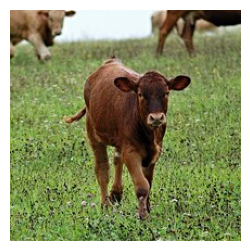

In [15]:
# DON'T MODIFY THIS CELL
from PIL import Image
def plot_image(image_tensor):
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    if image_tensor.shape[-1] == 3:
        ax.imshow(image_tensor,aspect=1)
    else:
        ax.imshow(image_tensor,aspect=1,cmap='gray')
    ax.axis('off')
    plt.show()

img_path = 'grass-field.jpg' 
original_image = np.array(Image.open(img_path).convert('RGB'))
plot_image(original_image)

## Task 4.1: image transformations
We can transform this image into a new one by acting on the tensor that encodes it:

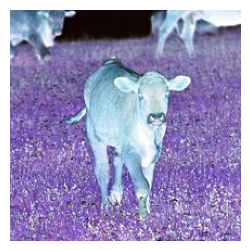

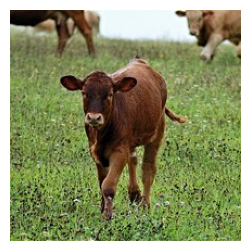

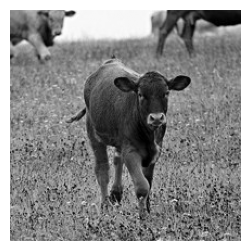

In [16]:
# DON'T MODIFY THIS CELL
reverse_color = lambda image: 255 - image
plot_image(reverse_color(original_image))
mirroring = lambda image: image[:, ::-1, :]
plot_image(mirroring(original_image))
grayscale = lambda image: image @ [0.3, 0.6, 0.1]
plot_image(grayscale(original_image))

The final function is the [color histogram](https://en.wikipedia.org/wiki/Color_histogram). This one is a bit lengthier, and the output is not an image anymore.

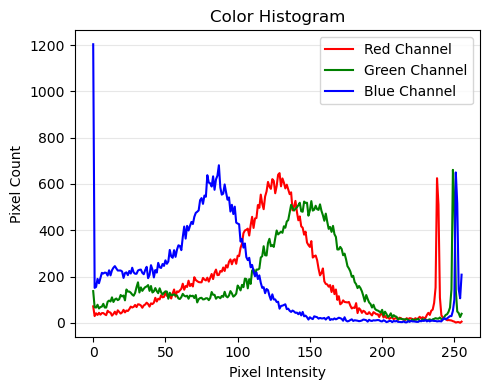

In [17]:
# DON'T MODIFY THIS CELL
def color_histogram(image):
    """
    Computes the Color Histogram of an RGB image.
    """
    color_hist = np.zeros((3, 256), dtype=int)
    for channel in range(3):
        color_hist[channel], _ = np.histogram(image[:, :, channel], bins=256, range=(0, 256))
    return color_hist

image_hist = color_histogram(original_image)

plt.figure(figsize=(5, 4))
for ii, color in enumerate(['red', 'green', 'blue']):
    plt.plot(image_hist[ii], color=color, label=f'{color.capitalize()} Channel')

plt.title('Color Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Pixel Count')
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Notice that the function `grayscale` takes the original image, an element of the set $[0, 255]^{H \times W \times 3}$, and outputs a new image from the set $[0, 255]^{H \times W}$. The domain of the function, the space to which the inputs belong, is different from the codomain, the space to which the outputs belong.
* Which is the domain and codomain of the other 3 functions, `reverse_color`, `mirroring`, and `color_histogram`?
* Are they invertible? If so, how?

## Solution

- **reverse_color**  
  Domain: $[0,255]^{H \times W \times 3}$  
  Codomain: $[0,255]^{H \times W \times 3}$  
  Invertible: Yes, since applying it twice returns the original image.

- **mirroring**  
  Domain: $[0,255]^{H \times W \times 3}$  
  Codomain: $[0,255]^{H \times W \times 3}$  
  Invertible: Yes, mirroring twice restores the original image.

- **color_histogram**  
  Domain: $[0,255]^{H \times W \times 3}$  
  Codomain: $\mathbb{N}^{3 \times 256}$  
  Invertible: No, since spatial information is lost and multiple images can have the same histogram.

## Task 4.2: two image transformations

For brevity, let's relabel the functions:`reverse_color`$\rightarrow r$, `mirroring`$\rightarrow m$, `grayscale`$\rightarrow s$, and `color_histogram`$\rightarrow h$.

Let's say you take the original image as input and apply 2 different functions from those we saw. These are function compositions, $(f\circ g)(x)=f(g(x))$, for some $f,g\in\{r,m,s,h\}$
* Which functions compositions, and in which order, can be applied?
* In which order can some function compositions NOT be applied? Why?
* BONUS: For the cases when $f(g(x))$ exist, but not $g(f(x))$, can you find a new function $g'$ such that $f(g(x)) = g'(f(x))$

Valid compositions:
- $r \circ r$, $r \circ m$, $m \circ r$, $m \circ m$
- $s \circ r$, $s \circ m$
- $h \circ r$, $h \circ m$

Invalid compositions:
- anything of the form $\_ \circ s$ or $\_ \circ h$

Reason:
- $s(x)$ is grayscale, not RGB
- $h(x)$ is a histogram, not RGB
- all functions $r,m,s,h$ expect RGB input

Bonus:
- $s \circ r = r' \circ s$ with $r'(y)=255-y$
- $s \circ m = m' \circ s$ with $m'(y)=y[:,::-1]$
- $h \circ r = r' \circ h$ with histogram bins reversed
- $h \circ m = h$, so $m'=\mathrm{id}$

## Function compositions

We relabel:

- $r$ = reverse_color
- $m$ = mirroring
- $s$ = grayscale
- $h$ = color_histogram

Their input/output spaces are:

- $r : [0,255]^{H \times W \times 3} \to [0,255]^{H \times W \times 3}$
- $m : [0,255]^{H \times W \times 3} \to [0,255]^{H \times W \times 3}$
- $s : [0,255]^{H \times W \times 3} \to [0,255]^{H \times W}$
- $h : [0,255]^{H \times W \times 3} \to \mathbb{N}^{3 \times 256}$

A composition $f \circ g$ is possible only if the codomain of $g$ matches the domain of $f$.

---

### 1. Valid compositions

Since $r,m,s,h$ all take RGB images as input, the second function $g$ must output an RGB image.  
Only $r$ and $m$ do that.

So the valid compositions are:

- $r \circ r$
- $r \circ m$
- $m \circ r$
- $m \circ m$
- $s \circ r$
- $s \circ m$
- $h \circ r$
- $h \circ m$

---

### 2. Invalid compositions

Any composition where the first applied function is $s$ or $h$ cannot be followed by any of $r,m,s,h$, because:

- $s(x)$ is grayscale, so its output is in $[0,255]^{H \times W}$
- $h(x)$ is a histogram, so its output is in $\mathbb{N}^{3 \times 256}$

But all four functions $r,m,s,h$ expect an RGB image as input.

So the following are **not defined**:

- $r \circ s$, $m \circ s$, $s \circ s$, $h \circ s$
- $r \circ h$, $m \circ h$, $s \circ h$, $h \circ h$

Reason: domain/codomain mismatch.

---

### 3. Order matters

Some compositions exist in one order but not in the other:

- $s \circ r$ exists, but $r \circ s$ does not
- $s \circ m$ exists, but $m \circ s$ does not
- $h \circ r$ exists, but $r \circ h$ does not
- $h \circ m$ exists, but $m \circ h$ does not

This happens because $r$ and $m$ preserve the RGB image format, while $s$ and $h$ change it.

---

### 4. Bonus

For some cases where $f(g(x))$ exists but $g(f(x))$ does not, we can define a new function $g'$ such that

$$
f(g(x)) = g'(f(x)).
$$

Examples:

#### Case 1: $s \circ r$

Grayscale after color inversion is:

$$
s(r(x))
$$

Since grayscale is linear,

$$
s(r(x)) = 255 - s(x)
$$

So define:

$$
r'(y) = 255 - y
$$

for grayscale images $y \in [0,255]^{H \times W}$.

Then:

$$
s(r(x)) = r'(s(x))
$$

---

#### Case 2: $s \circ m$

Mirroring before grayscale gives:

$$
s(m(x))
$$

This is the same as mirroring the grayscale image, so define $m'$ on grayscale images by horizontal flipping:

$$
m'(y) = y[:, ::-1]
$$

Then:

$$
s(m(x)) = m'(s(x))
$$

---

#### Case 3: $h \circ r$

Color inversion changes each channel histogram by reversing the intensity axis.  
So define $r'$ on histograms as:

$$
r'(H)[:,i] = H[:,255-i]
$$

Then:

$$
h(r(x)) = r'(h(x))
$$

---

#### Case 4: $h \circ m$

Mirroring does not change how many pixels of each intensity exist, only where they are.  
So the histogram stays unchanged. Define:

$$
m'(H) = H
$$

Then:

$$
h(m(x)) = m'(h(x)) = h(x)
$$